# Observed projections of the Clouds at present day

In [50]:
import astropy.coordinates as coord
import astropy.units as u
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import plots_init as pi
import snap_analysis as sna
import transform_galaxy as tg
from matplotlib.colors import LogNorm
# from mw_plot import MWSkyMap
# %pip install mw-plot
# %pip install bokeh

## Loading present day snapshot

In [51]:
snap_idx = 400  # NOTE: this is technically 1 snapshot before the orbit determined present day
snap = (
    "/xdisk/gbesla/himansh/gadget4/lmc_smc_mw/lmcsmcmw25/sim/output/snap_" + str(snap_idx) + ".hdf5"
)

In [52]:
N_LMC = int(1.16e7 + 1)  # total number of particles in the LMC
N_SMC = int(1.544e6 + 1)  # total number of particles in the SMC

## Loading MW center

In [53]:
mw_com_pos = np.load("./com_orbit/data/MW_com_pos.npy")[:, snap_idx]

## Extracting LMC and SMC positions

In [54]:
pos_stars_all = sna.get_positions(snap, "PartType2")
pids_stars_all = sna.get_particle_ids(snap, "PartType2")

# extract LMC
LMC_idxs = (pids_stars_all > 0) & (pids_stars_all <= N_LMC)
lmc_pos_stars = pos_stars_all[:, LMC_idxs]

# extract SMC
SMC_idxs = (pids_stars_all > N_LMC) & (pids_stars_all <= N_LMC + N_SMC)
smc_pos_stars = pos_stars_all[:, SMC_idxs]

In [55]:
# Aligning to galactocentric frame
lmc_pos_stars = tg.transGal.translate_gal(lmc_pos_stars, mw_com_pos)
smc_pos_stars = tg.transGal.translate_gal(smc_pos_stars, mw_com_pos)

combined_pos_stars = np.concatenate((lmc_pos_stars, smc_pos_stars), axis=1)

## Creating astropy coordinates

In [56]:
combined_pos_stars_galcen = coord.SkyCoord(
    x=combined_pos_stars[0, :] * u.kpc,
    y=combined_pos_stars[1, :] * u.kpc,
    z=combined_pos_stars[2, :] * u.kpc,
    frame="galactocentric",
)

## RA-DEC projections

In [57]:
# Transform to the ICRS frame
combined_pos_stars_icrs = combined_pos_stars_galcen.transform_to(coord.ICRS)

In [58]:
# Extract RA and DEC
ra = combined_pos_stars_icrs.ra.degree
dec = combined_pos_stars_icrs.dec.degree
ra[ra > 180] = ra[ra > 180] - 360

### Plotting the RA-DEC view of the Clouds

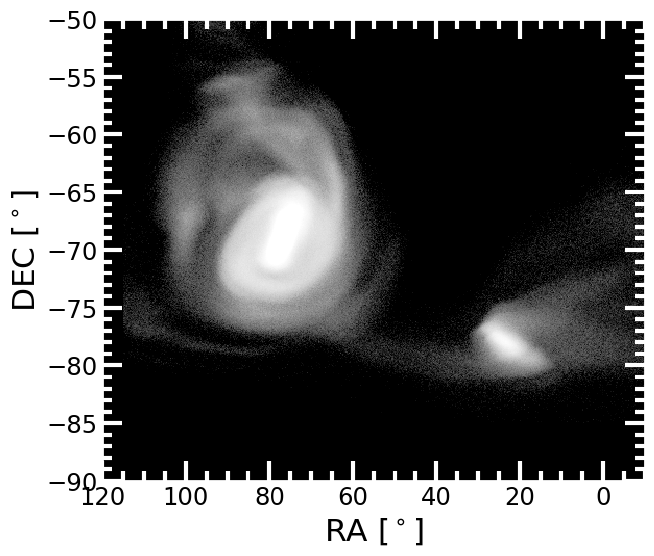

In [59]:
ra_llim, ra_ulim = -10, 115
dec_llim, dec_ulim = -85, -40

fig = plt.figure(figsize=(7, 6))
ax0 = fig.add_subplot(1, 1, 1)
ax0.set_facecolor("k")
_, _, _, im = ax0.hist2d(
    ra,
    dec,
    range=((ra_llim, ra_ulim), (dec_llim, dec_ulim)),
    bins=500,
    cmap=plt.cm.Grays.reversed(),
    norm=LogNorm(vmin=5, vmax=1e3),
)
# fig.colorbar(mappable = im, ax = ax0)
ax0.set_xlim(ra_ulim + 5, ra_llim)
# ax0.set_ylim(dec_llim-10, dec_ulim+10)
ax0.set_ylim(-90, -50)
ax0.tick_params(which="both", color="white")
ax0.spines[["top", "bottom", "right", "left"]].set_color("white")
ax0.set_xlabel(r"RA [$^\circ$]")
ax0.set_ylabel(r"DEC [$^\circ$]")
pi.aesthetic(ax0)
# plt.savefig("clouds_ra_dec_simulated.jpg", bbox_inches = "tight", dpi = 300)
plt.show()

## Galactic projections

<Figure size 800x600 with 0 Axes>

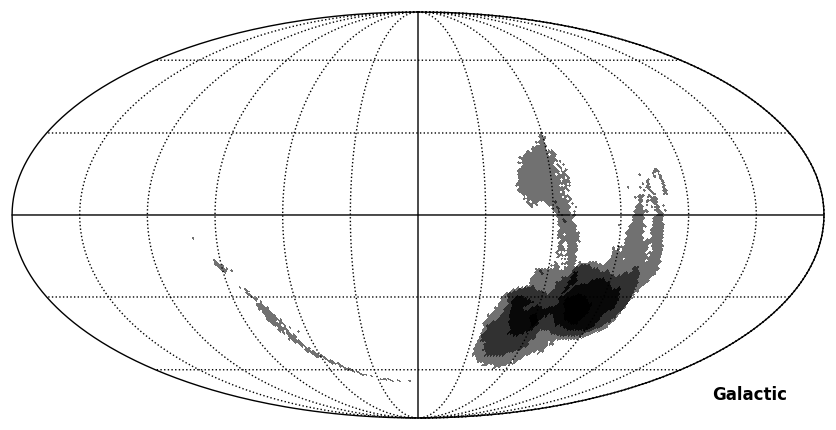

In [ ]:
# Transform to galactic frame
combined_galactic = combined_pos_stars_galcen.galactic

# histogramming to create a map in (l, b)
l_gal = (combined_galactic.l).value
b_gal = (combined_galactic.b).value

# converting to a healpix map
NSIDE = 64
"""
print(
    "Approximate resolution at NSIDE {} is {:.2} deg".format(
        NSIDE, hp.nside2resol(NSIDE, arcmin=True) / 60
    )
)
"""
NPIX = hp.nside2npix(NSIDE)
indices = hp.ang2pix(NSIDE, l_gal, b_gal, lonlat=True)
smc_hpx_map = np.zeros(NPIX, dtype=int)
idx, counts = np.unique(indices, return_counts=True)
smc_hpx_map[idx] = np.log10(counts)

fig = plt.figure(figsize=(8, 6))
hp.mollview(
    smc_hpx_map,
    coord="G",
    title="",
    unit=r"$\log({\rm Counts})$",
    cbar=False,
    norm="hist",
    cmap=plt.cm.gray.reversed(),
    min=0.001,
    max=100,
)
hp.graticule()
# plt.savefig("clouds_galactic_simulated.jpg", bbox_inches = "tight", dpi = 300)
plt.show()

## Magellanic stream coordinates

In [61]:
# from Nidever et al. 2008
# %pip install gala
from gala.coordinates import MagellanicStreamNidever08

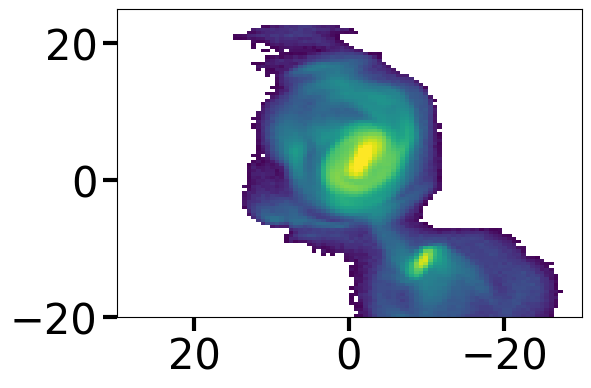

In [79]:
ms_coords = combined_pos_stars_galcen.transform_to(MagellanicStreamNidever08())
L_ms = ms_coords.L.wrap_at(180 * u.deg).degree
B_ms = ms_coords.B.degree
my_cmap = plt.cm.viridis
my_cmap.set_bad(color="white")
my_cmap.set_under(color="white")

fig, ax = plt.subplots(figsize=(6, 4))
# Plot the particles
_, _, _, im = ax.hist2d(
    L_ms,
    B_ms,
    bins=100,
    range=((-30, 30), (-20, 25)),
    cmap=my_cmap,
    norm=LogNorm(vmin=6e1, vmax=5e4),
)
# fig.colorbar(mappable = im, ax = ax)
# Formatting standard for sky maps
# ax.set_xlabel('$L_{MS}$ (deg)')
# ax.set_ylabel('$B_{MS}$ (deg)')
# Invert X-axis so East is to the left, a standard convention in astronomy
ax.invert_xaxis()
# Set standard limits for the MS (-180 to 180 longitude, -90 to 90 latitude)
ax.set_xlim(30, -30)
ax.set_ylim(-20, 25)

ax.set_xticks([-20, 0, 20])
ax.set_yticks([-20, 0, 20])
ax.tick_params(labelsize=30, width=3, length=10)

plt.savefig("clouds_ms_simulated.jpg", dpi=300, bbox_inches="tight")
plt.show()